In [21]:
#1.anomaly detction
import pandas as pd
df=pd.read_csv("creditcard.csv")
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


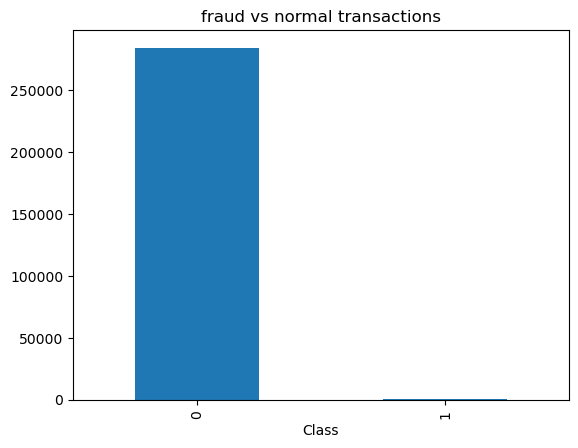

In [22]:
#visulization

import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.title("fraud vs normal transactions")
plt.show()

In [23]:
#2.machine learning models

#prepare data
from sklearn.model_selection import train_test_split

x=df.drop('Class',axis=1)
y=df['Class']

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [25]:
#logistic regression
model=LogisticRegression(max_iter=5000,solver='liblinear')
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.9989993328885924


In [26]:
#decision tree
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.9991748885221726


In [27]:
#3.feature engineering
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
df['Amount']=scaler.fit_transform(df[['Amount']])


In [28]:
#4.real-time monitoring
sample=x_test.iloc[0:1]

prediction=model.predict(sample)

print("Fraud" if prediction[0]==1 else "Normal")

Fraud


In [29]:
#5.scalabity

print("dataset shape:",df.shape)

dataset shape: (284807, 31)


In [30]:

print("\nconfusion matrix:\n",confusion_matrix(y_test,y_pred))
print("\nclassifcation report:\n",classification_report(y_test,y_pred))


confusion matrix:
 [[56833    31]
 [   16    82]]

classifcation report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.84      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962

